In [16]:
# Instala a biblioteca "redis" no ambiente do Jupyter/Python.
# O ponto de exclamação "!" é um recurso do Jupyter Notebook:
# ele permite executar comandos do sistema operacional / terminal
# diretamente dentro da célula.
# Neste caso, estamos rodando o comando:
# pip install redis
# que instala o pacote necessário para o Python conversar com o Redis.

!pip install redis

In [17]:
# Importa a biblioteca padrão "json".
# Essa biblioteca serve para:
# - ler arquivos JSON
# - converter texto JSON em objeto Python
# - converter objeto Python em texto JSON
import json

# Importa a biblioteca "redis", que contém a classe Redis
# e os métodos usados para conectar, salvar e ler dados no Redis.
import redis

# Importa a função pprint ("pretty print").
# Ela mostra estruturas grandes (como dicionários e listas)
# de forma mais organizada do que o print comum.
from pprint import pprint

# Cria uma variável chamada caminho_arquivo.
# Variável = um nome que guarda um valor.
# Aqui, esse valor é o caminho completo do arquivo JSON no Windows.
caminho_arquivo = r"C:\Users\User\Documents\FATESG\Banco de dados não relacional\Redis-Interface\Data\dados_alunos_redis.json"

# O prefixo r antes das aspas significa "raw string" (string bruta).
# Isso diz ao Python para interpretar as barras invertidas "\" literalmente.
# Sem esse r, o Python poderia tentar entender sequências como:
# \n = quebra de linha
# \t = tab
# Como caminho de Windows usa muitas barras invertidas,
# o r ajuda a evitar erro e facilita a escrita do caminho.

# Mostra o caminho salvo na variável para conferência.
print("Caminho do arquivo JSON:")
print(caminho_arquivo)

Caminho do arquivo JSON:
C:\Users\User\Documents\FATESG\Banco de dados não relacional\Redis-Interface\Data\dados_alunos_redis.json


In [18]:
# Abre o arquivo usando a função open(...).
# A estrutura "with ... as ..." é a forma recomendada de abrir arquivos,
# porque ela garante que o arquivo será fechado automaticamente
# ao final do bloco, mesmo se acontecer erro no meio.
with open(caminho_arquivo, "r", encoding="utf-8") as f:
    # caminho_arquivo:
    #   é a variável que contém o endereço do arquivo no disco.
    #
    # "r":
    #   é o modo de abertura do arquivo.
    #   "r" vem de "read" = leitura.
    #   Isso quer dizer: vamos apenas ler o arquivo, não escrever nele.
    #
    # encoding="utf-8":
    #   define a codificação de texto usada para interpretar o conteúdo.
    #   UTF-8 é a codificação mais comum e suporta acentos e caracteres especiais.
    #
    # as f:
    #   significa que o arquivo aberto será referenciado pela variável f.
    #   Dentro do bloco, "f" representa esse arquivo.
    
    # json.load(f):
    # - json = biblioteca importada lá em cima
    # - load = método para ler JSON de um ARQUIVO
    # - f = arquivo já aberto
    #
    # Esse comando lê o conteúdo do arquivo JSON e converte
    # automaticamente para um objeto Python.
    #
    # Se o arquivo tiver:
    #   { ... }  -> vira um dict (dicionário)
    #   [ ... ]  -> vira uma list (lista)
    dados = json.load(f)

# Mostra o tipo do objeto carregado.
# type(dados) retorna a classe/tipo do conteúdo.
# Isso ajuda a saber se o JSON era um objeto ou uma lista.
print("Tipo do conteúdo carregado:")
print(type(dados))

# Mostra o conteúdo carregado de forma organizada.
# pprint = pretty print = impressão mais legível.
print("\nConteúdo do JSON lido do arquivo:")
pprint(dados)

Tipo do conteúdo carregado:
<class 'dict'>

Conteúdo do JSON lido do arquivo:
{'aluno:1001': {'curso': 'Ciência da Computação',
                'disciplinas': ['Estrutura de Dados', 'Bancos de Dados', 'IA'],
                'idade': 22,
                'nome': 'Jefferson Silva',
                'semestre': 4,
                'status': 'Ativo'},
 'aluno:1002': {'curso': 'Engenharia de Software',
                'disciplinas': ['Cálculo I', 'Lógica de Programação'],
                'idade': 20,
                'nome': 'Ana Beatriz Oliveira',
                'semestre': 2,
                'status': 'Ativo'},
 'aluno:1003': {'curso': 'Sistemas de Informação',
                'disciplinas': ['Gestão de Projetos',
                                'Segurança da Informação'],
                'idade': 25,
                'nome': 'Lucas Marcante',
                'semestre': 8,
                'status': 'Formando'},
 'aluno:1004': {'curso': 'Análise e Desenvolvimento de Sistemas',
               

In [19]:
# Cria a conexão com o Redis.
# redis.Redis(...) instancia um cliente/objeto de conexão.
# O nome da variável "r" é apenas uma convenção curta.
# Poderia ser "cliente", "conexao" ou outro nome qualquer.
r = redis.Redis(
    host="127.0.0.1",      # host = endereço do servidor Redis
                            # 127.0.0.1 significa "esta própria máquina" (localhost)
                            # Como seu código está rodando no Windows/host,
                            # e o Redis publicou a porta 6379, isso funciona.

    port=6379,             # port = porta de comunicação do Redis
                            # 6379 é a porta padrão do Redis

    decode_responses=True  # por padrão, muitas respostas do Redis vêm em bytes
                            # com True, a biblioteca converte automaticamente
                            # essas respostas para string normal do Python
                            # isso facilita leitura e manipulação
)

# Envia o comando PING para o Redis.
# ping() é um teste simples de conectividade.
# Se a conexão estiver funcionando, o retorno normalmente será True.
print("Resultado do teste de conexão com Redis:")
print(r.ping())

Resultado do teste de conexão com Redis:
True


In [20]:
# Define o nome da chave que será criada no Redis.
# No Redis, tudo é armazenado em pares:
# chave -> valor
#
# Aqui:
# chave = "json:alunos:arquivo"
# valor = será o conteúdo do JSON
#
# Esse padrão com ":" é muito usado para organizar nomes de chave.
# Exemplo:
# json:alunos:arquivo
# json:clientes:2026
# aluno:1
chave_redis = "json:alunos:arquivo"

# Converte o objeto Python armazenado em "dados" para TEXTO JSON.
# json.dumps(...) faz o caminho inverso do json.load(...):
#
# json.load(...)   -> arquivo JSON  -> objeto Python
# json.dumps(...)  -> objeto Python -> string JSON
json_texto = json.dumps(
    dados,                 # objeto Python que queremos transformar em JSON texto
    ensure_ascii=False,    # mantém caracteres acentuados normalmente
                           # se fosse True, alguns caracteres poderiam virar sequências escapadas
                           # como \u00e1 etc.

    indent=2               # adiciona identação de 2 espaços
                           # isso deixa o JSON salvo mais bonito e legível
)

# Salva no Redis usando o método set(...).
# set(chave, valor) significa:
# "grave este valor nesta chave"
#
# Aqui:
# - chave_redis = nome da chave
# - json_texto  = valor a ser salvo
r.set(chave_redis, json_texto)

# Exibe mensagem de confirmação.
print(f"JSON salvo com sucesso na chave: {chave_redis}")

JSON salvo com sucesso na chave: json:alunos:arquivo


In [21]:
# Busca do Redis o valor associado à chave informada.
# get(chave) = "me devolva o conteúdo salvo nessa chave"
valor_salvo = r.get(chave_redis)

# Mostra o tipo do valor retornado.
# Como usamos decode_responses=True,
# o retorno deverá ser uma string Python, não bytes.
print("Tipo do valor retornado pelo Redis:")
print(type(valor_salvo))

# Exibe o conteúdo bruto, exatamente como foi salvo.
# Neste caso, deve aparecer o JSON em formato texto.
print("\nValor salvo no Redis:")
print(valor_salvo)

Tipo do valor retornado pelo Redis:
<class 'str'>

Valor salvo no Redis:
{
  "aluno:1001": {
    "nome": "Jefferson Silva",
    "idade": 22,
    "curso": "Ciência da Computação",
    "semestre": 4,
    "status": "Ativo",
    "disciplinas": [
      "Estrutura de Dados",
      "Bancos de Dados",
      "IA"
    ]
  },
  "aluno:1002": {
    "nome": "Ana Beatriz Oliveira",
    "idade": 20,
    "curso": "Engenharia de Software",
    "semestre": 2,
    "status": "Ativo",
    "disciplinas": [
      "Cálculo I",
      "Lógica de Programação"
    ]
  },
  "aluno:1003": {
    "nome": "Lucas Marcante",
    "idade": 25,
    "curso": "Sistemas de Informação",
    "semestre": 8,
    "status": "Formando",
    "disciplinas": [
      "Gestão de Projetos",
      "Segurança da Informação"
    ]
  },
  "aluno:1004": {
    "nome": "Mariana Costa",
    "idade": 21,
    "curso": "Análise e Desenvolvimento de Sistemas",
    "semestre": 3,
    "status": "Ativo",
    "disciplinas": [
      "Desenvolvimento Web",

In [22]:
# Converte novamente a string JSON lida do Redis para objeto Python.
# Aqui usamos json.loads(...), com "s" no final.
#
# Diferença:
# json.load(arquivo_aberto)   -> lê JSON de arquivo
# json.loads(texto_json)      -> lê JSON de string
dados_recuperados = json.loads(valor_salvo)

# Mostra o tipo do objeto recuperado após a conversão.
print("Tipo do objeto recuperado a partir do texto JSON:")
print(type(dados_recuperados))

# Exibe o conteúdo convertido de volta para Python.
# Se o JSON original era objeto, aqui será dict.
# Se era lista, aqui será list.
print("\nConteúdo recuperado do Redis e convertido para Python:")
pprint(dados_recuperados)

Tipo do objeto recuperado a partir do texto JSON:
<class 'dict'>

Conteúdo recuperado do Redis e convertido para Python:
{'aluno:1001': {'curso': 'Ciência da Computação',
                'disciplinas': ['Estrutura de Dados', 'Bancos de Dados', 'IA'],
                'idade': 22,
                'nome': 'Jefferson Silva',
                'semestre': 4,
                'status': 'Ativo'},
 'aluno:1002': {'curso': 'Engenharia de Software',
                'disciplinas': ['Cálculo I', 'Lógica de Programação'],
                'idade': 20,
                'nome': 'Ana Beatriz Oliveira',
                'semestre': 2,
                'status': 'Ativo'},
 'aluno:1003': {'curso': 'Sistemas de Informação',
                'disciplinas': ['Gestão de Projetos',
                                'Segurança da Informação'],
                'idade': 25,
                'nome': 'Lucas Marcante',
                'semestre': 8,
                'status': 'Formando'},
 'aluno:1004': {'curso': 'Análise e De

Imagem salva no Redis com a chave: image:aluno_brito


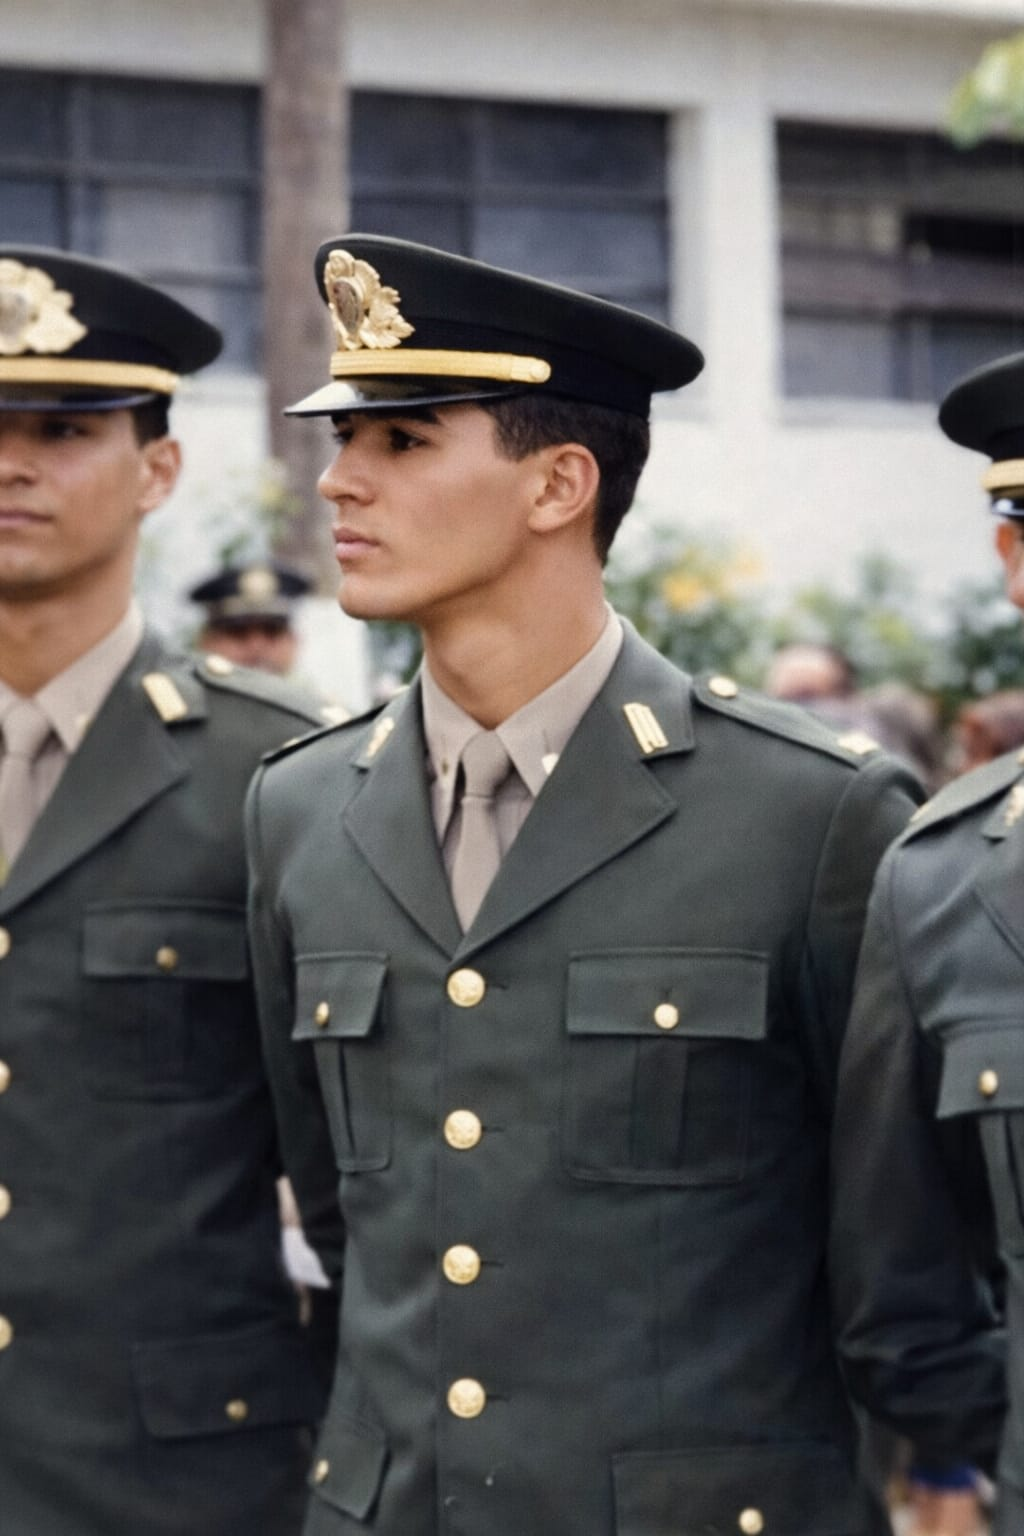

In [23]:
# Importa a biblioteca base64 para codificação/decodificação
import base64
from IPython.display import Image, display

# Caminho da imagem
caminho_imagem = r"C:\Users\User\Documents\FATESG\Banco de dados não relacional\Redis-Interface\Aluno Brito.jpeg"

# Lê a imagem em modo binário
with open(caminho_imagem, "rb") as f:
    dados_imagem = f.read()

# Codifica para base64
imagem_base64 = base64.b64encode(dados_imagem).decode('utf-8')

# Salva no Redis
chave_imagem = "image:aluno_brito"
r.set(chave_imagem, imagem_base64)

print(f"Imagem salva no Redis com a chave: {chave_imagem}")

# Recupera do Redis
imagem_recuperada_base64 = r.get(chave_imagem)

# Decodifica de base64
dados_imagem_recuperada = base64.b64decode(imagem_recuperada_base64)

# Exibe a imagem
display(Image(data=dados_imagem_recuperada))